In [1]:
import numpy as np
import pandas as pd
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(10, 6))
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_columns = 20
pd.options.display.max_rows = 20
pd.options.display.max_colwidth = 80
np.set_printoptions(precision=4, suppress=True)

In [2]:
import numpy as np
import pandas as pd

In [4]:
from datetime import datetime
now = datetime.now()
now
now.year, now.month, now.day

(2026, 6, 26)

In [6]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)
delta
delta.days
delta.seconds

56700

In [9]:
from datetime import timedelta
start = datetime(2011, 1, 7)
start + timedelta(12)
start - 2 * timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

In [8]:
stamp = datetime(2011, 1, 3)
str(stamp)
stamp.strftime("%Y-%m-%d")

'2011-01-03'

In [12]:
value = "2011-01-03"
datetime.strptime(value, "%Y-%m-%d")
datestrs = ["7/6/2011", "8/6/2011"]
[datetime.strptime(x, "%m/%d/%Y") for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

In [13]:
datestrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00"]
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[us]', freq=None)

In [14]:
idx = pd.to_datetime(datestrs + [None])
idx
idx[2]
pd.isna(idx)

array([False, False,  True])

In [15]:
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]
ts = pd.Series(np.random.standard_normal(6), index=dates)
ts

2011-01-02   -0.204708
2011-01-05    0.478943
2011-01-07   -0.519439
2011-01-08   -0.555730
2011-01-10    1.965781
2011-01-12    1.393406
dtype: float64

In [16]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[us]', freq=None)

In [17]:
ts + ts[::2]

2011-01-02   -0.409415
2011-01-05         NaN
2011-01-07   -1.038877
2011-01-08         NaN
2011-01-10    3.931561
2011-01-12         NaN
dtype: float64

In [18]:
ts.index.dtype

dtype('<M8[us]')

In [19]:
stamp = ts.index[0]
stamp

Timestamp('2011-01-02 00:00:00')

In [20]:
stamp = ts.index[2]
ts[stamp]

np.float64(-0.5194387150567381)

In [16]:
ts["2011-01-10"]

In [21]:
longer_ts = pd.Series(np.random.standard_normal(1000),
                      index=pd.date_range("2000-01-01", periods=1000))
longer_ts
longer_ts["2001"]

2001-01-01    1.599534
2001-01-02    0.474071
2001-01-03    0.151326
2001-01-04   -0.542173
2001-01-05   -0.475496
                ...   
2001-12-27    0.057874
2001-12-28   -0.433739
2001-12-29    0.092698
2001-12-30   -1.397820
2001-12-31    1.457823
Freq: D, Length: 365, dtype: float64

In [18]:
longer_ts["2001-05"]

In [19]:
ts[datetime(2011, 1, 7):]
ts[datetime(2011, 1, 7):datetime(2011, 1, 10)]

In [20]:
ts
ts["2011-01-06":"2011-01-11"]

In [21]:
ts.truncate(after="2011-01-09")

In [22]:
dates = pd.date_range("2000-01-01", periods=100, freq="W-WED")
long_df = pd.DataFrame(np.random.standard_normal((100, 4)),
                       index=dates,
                       columns=["Colorado", "Texas",
                                "New York", "Ohio"])
long_df.loc["2001-05"]

,Colorado,Texas,New York,Ohio
2001-05-02,-0.006045,0.490094,-0.277186,-0.707213
2001-05-09,-0.560107,2.735527,0.927335,1.513906
2001-05-16,0.538600,1.273768,0.667876,-0.969206
2001-05-23,1.676091,-0.817649,0.050188,1.951312
2001-05-30,3.260383,0.963301,1.201206,-1.852001


In [23]:
dates = pd.DatetimeIndex(["2000-01-01", "2000-01-02", "2000-01-02",
                          "2000-01-02", "2000-01-03"])
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

In [24]:
dup_ts.index.is_unique

False

In [25]:
dup_ts["2000-01-03"]  # not duplicated
dup_ts["2000-01-02"]  # duplicated

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

In [26]:
grouped = dup_ts.groupby(level=0)
grouped.mean()
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

In [27]:
ts
resampler = ts.resample("D")
resampler

In [28]:
index = pd.date_range("2012-04-01", "2012-06-01")
index

In [29]:
pd.date_range(start="2012-04-01", periods=20)
pd.date_range(end="2012-06-01", periods=20)

In [30]:
pd.date_range("2000-01-01", "2000-12-01", freq="BM")

In [31]:
pd.date_range("2012-05-02 12:56:31", periods=5)

In [28]:
pd.date_range("2012-05-02 12:56:31", periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[us]', freq='D')

In [29]:
from pandas.tseries.offsets import Hour, Minute
hour = Hour()
hour

<Hour>

In [34]:
four_hours = Hour(4)
four_hours

In [35]:
pd.date_range("2000-01-01", "2000-01-03 23:59", freq="4H")

In [36]:
Hour(2) + Minute(30)

In [37]:
pd.date_range("2000-01-01", periods=10, freq="1h30min")

In [30]:
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq="WOM-3FRI")
list(monthly_dates)

[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

In [31]:
ts = pd.Series(np.random.standard_normal(4),
               index=pd.date_range("2000-01-01", periods=4, freq="M"))
ts
ts.shift(2)
ts.shift(-2)

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [32]:
ts.shift(2, freq="M")

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [34]:
ts.shift(3, freq="D")
ts.shift(1, freq="90T")

ValueError: Invalid frequency: 90T. Failed to parse with error message: ValueError("Invalid frequency: T. Failed to parse with error message: KeyError('T'). Did you mean min?")

In [33]:
from pandas.tseries.offsets import Day, MonthEnd
now = datetime(2011, 11, 17)
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

In [35]:
now + MonthEnd()
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [36]:
offset = MonthEnd()
offset.rollforward(now)
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

In [37]:
ts = pd.Series(np.random.standard_normal(20),
               index=pd.date_range("2000-01-15", periods=20, freq="4D"))
ts
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.005833
2000-02-29    0.015894
2000-03-31    0.150209
dtype: float64

In [38]:
ts.resample("M").mean()

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [39]:
import pytz
pytz.common_timezones[-5:]

ModuleNotFoundError: No module named 'pytz'

In [48]:
tz = pytz.timezone("America/New_York")
tz

In [40]:
dates = pd.date_range("2012-03-09 09:30", periods=6)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-03-09 09:30:00   -0.202469
2012-03-10 09:30:00    0.050718
2012-03-11 09:30:00    0.639869
2012-03-12 09:30:00    0.597594
2012-03-13 09:30:00   -0.797246
2012-03-14 09:30:00    0.472879
Freq: D, dtype: float64

In [41]:
print(ts.index.tz)

None


In [42]:
pd.date_range("2012-03-09 09:30", periods=10, tz="UTC")

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[us, UTC]', freq='D')

In [43]:
ts
ts_utc = ts.tz_localize("UTC")
ts_utc
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[us, UTC]', freq='D')

In [44]:
ts_utc.tz_convert("America/New_York")

2012-03-09 04:30:00-05:00   -0.202469
2012-03-10 04:30:00-05:00    0.050718
2012-03-11 05:30:00-04:00    0.639869
2012-03-12 05:30:00-04:00    0.597594
2012-03-13 05:30:00-04:00   -0.797246
2012-03-14 05:30:00-04:00    0.472879
dtype: float64

In [54]:
ts_eastern = ts.tz_localize("America/New_York")
ts_eastern.tz_convert("UTC")
ts_eastern.tz_convert("Europe/Berlin")

In [55]:
ts.index.tz_localize("Asia/Shanghai")

In [45]:
stamp = pd.Timestamp("2011-03-12 04:00")
stamp_utc = stamp.tz_localize("utc")
stamp_utc.tz_convert("America/New_York")

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

In [46]:
stamp_moscow = pd.Timestamp("2011-03-12 04:00", tz="Europe/Moscow")
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

In [47]:
stamp_utc.value
stamp_utc.tz_convert("America/New_York").value

1299902400000000000

In [48]:
stamp = pd.Timestamp("2012-03-11 01:30", tz="US/Eastern")
stamp
stamp + Hour()

Timestamp('2012-03-11 03:30:00-0400', tz='US/Eastern')

In [49]:
stamp = pd.Timestamp("2012-11-04 00:30", tz="US/Eastern")
stamp
stamp + 2 * Hour()

Timestamp('2012-11-04 01:30:00-0500', tz='US/Eastern')

In [50]:
dates = pd.date_range("2012-03-07 09:30", periods=10, freq="B")
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts
ts1 = ts[:7].tz_localize("Europe/London")
ts2 = ts1[2:].tz_convert("Europe/Moscow")
result = ts1 + ts2
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

In [51]:
p = pd.Period("2011", freq="A-DEC")
p

ValueError: Invalid frequency: A-DEC. Failed to parse with error message: ValueError("Invalid frequency: A-DEC. Failed to parse with error message: KeyError('A'). Did you mean Y-DEC?") Did you mean Y-DEC?

In [52]:
p + 5
p - 2

NameError: name 'p' is not defined

In [53]:
pd.Period("2014", freq="A-DEC") - p

ValueError: Invalid frequency: A-DEC. Failed to parse with error message: ValueError("Invalid frequency: A-DEC. Failed to parse with error message: KeyError('A'). Did you mean Y-DEC?") Did you mean Y-DEC?

In [54]:
periods = pd.period_range("2000-01-01", "2000-06-30", freq="M")
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [56]:
pd.Series(np.random.standard_normal(6), index=periods)

2000-01   -0.514551
2000-02   -0.559782
2000-03   -0.783408
2000-04   -1.797685
2000-05   -0.172670
2000-06    0.680215
Freq: M, dtype: float64

In [57]:
values = ["2001Q3", "2002Q2", "2003Q1"]
index = pd.PeriodIndex(values, freq="Q-DEC")
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

In [58]:
p = pd.Period("2011", freq="A-DEC")
p
p.asfreq("M", how="start")
p.asfreq("M", how="end")
p.asfreq("M")

ValueError: Invalid frequency: A-DEC. Failed to parse with error message: ValueError("Invalid frequency: A-DEC. Failed to parse with error message: KeyError('A'). Did you mean Y-DEC?") Did you mean Y-DEC?

In [59]:
p = pd.Period("2011", freq="A-JUN")
p
p.asfreq("M", how="start")
p.asfreq("M", how="end")

ValueError: Invalid frequency: A-JUN. Failed to parse with error message: ValueError("Invalid frequency: A-JUN. Failed to parse with error message: KeyError('A'). Did you mean Y-JUN?") Did you mean Y-JUN?

In [60]:
p = pd.Period("Aug-2011", "M")
p.asfreq("A-JUN")

ValueError: Invalid frequency: A-JUN. Failed to parse with error message: ValueError("Invalid frequency: A-JUN. Failed to parse with error message: KeyError('A'). Did you mean Y-JUN?") Did you mean Y-JUN?

In [61]:
periods = pd.period_range("2006", "2009", freq="A-DEC")
ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)
ts
ts.asfreq("M", how="start")

ValueError: Invalid frequency: A-DEC. Failed to parse with error message: ValueError("Invalid frequency: A-DEC. Failed to parse with error message: KeyError('A'). Did you mean Y-DEC?") Did you mean Y-DEC?

In [62]:
ts.asfreq("B", how="end")

2012-03-07 09:30:00    0.522356
2012-03-08 09:30:00   -0.546348
2012-03-09 09:30:00   -0.733537
2012-03-12 09:30:00    1.302736
2012-03-13 09:30:00    0.022199
2012-03-14 09:30:00    0.364287
2012-03-15 09:30:00   -0.922839
2012-03-16 09:30:00    0.312656
2012-03-19 09:30:00   -1.128497
2012-03-20 09:30:00   -0.333488
Freq: B, dtype: float64

In [63]:
p = pd.Period("2012Q4", freq="Q-JAN")
p

Period('2012Q4', 'Q-JAN')

In [64]:
p.asfreq("D", how="start")
p.asfreq("D", how="end")

Period('2012-01-31', 'D')

In [65]:
p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60
p4pm
p4pm.to_timestamp()

C:\Users\Michał\AppData\Local\Temp\ipykernel_15488\1108768030.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq("B", how="end") - 1).asfreq("T", how="start") + 16 * 60


ValueError: Invalid frequency: T. Failed to parse with error message: ValueError("Invalid frequency: T. Failed to parse with error message: KeyError('T'). Did you mean min?") Did you mean min?

In [66]:
periods = pd.period_range("2011Q3", "2012Q4", freq="Q-JAN")
ts = pd.Series(np.arange(len(periods)), index=periods)
ts
new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16
ts.index = new_periods.to_timestamp()
ts

C:\Users\Michał\AppData\Local\Temp\ipykernel_15488\142431650.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16


ValueError: Invalid frequency: H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?") Did you mean h?

In [67]:
dates = pd.date_range("2000-01-01", periods=3, freq="M")
ts = pd.Series(np.random.standard_normal(3), index=dates)
ts
pts = ts.to_period()
pts

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [70]:
dates = pd.date_range("2000-01-29", periods=6)
ts2 = pd.Series(np.random.standard_normal(6), index=dates)
ts2
ts2.to_period("M")

2000-01    1.521760
2000-01    0.244175
2000-01    0.423331
2000-02   -0.654040
2000-02    2.089154
2000-02   -0.060220
Freq: M, dtype: float64

In [69]:
pts = ts2.to_period()
pts
pts.to_timestamp(how="end")

2000-01-29 23:59:59.999999    1.607578
2000-01-30 23:59:59.999999    0.200381
2000-01-31 23:59:59.999999   -0.834068
2000-02-01 23:59:59.999999   -0.302988
2000-02-02 23:59:59.999999    1.663261
2000-02-03 23:59:59.999999   -0.996206
Freq: D, dtype: float64

In [73]:
data = pd.read_csv("examples/macrodata.csv")
data.head(5)
data["year"]
data["quarter"]

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

In [74]:
index = pd.PeriodIndex(year=data["year"], quarter=data["quarter"],
                       freq="Q-DEC")
index
data.index = index
data["infl"]

TypeError: PeriodIndex.__new__() got an unexpected keyword argument 'year'

In [75]:
dates = pd.date_range("2000-01-01", periods=100)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts
ts.resample("M").mean()
ts.resample("M", kind="period").mean()

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [76]:
dates = pd.date_range("2000-01-01", periods=12, freq="T")
ts = pd.Series(np.arange(len(dates)), index=dates)
ts

ValueError: Invalid frequency: T. Failed to parse with error message: ValueError("Invalid frequency: T. Failed to parse with error message: KeyError('T'). Did you mean min?") Did you mean min?

In [77]:
ts.resample("5min").sum()

2000-01-01 00:00:00   -0.167933
2000-01-01 00:05:00    0.000000
2000-01-01 00:10:00    0.000000
2000-01-01 00:15:00    0.000000
2000-01-01 00:20:00    0.000000
                         ...   
2000-04-08 23:40:00    0.000000
2000-04-08 23:45:00    0.000000
2000-04-08 23:50:00    0.000000
2000-04-08 23:55:00    0.000000
2000-04-09 00:00:00   -2.253294
Freq: 5min, Length: 28513, dtype: float64

In [78]:
ts.resample("5min", closed="right").sum()

1999-12-31 23:55:00   -0.167933
2000-01-01 00:00:00    0.000000
2000-01-01 00:05:00    0.000000
2000-01-01 00:10:00    0.000000
2000-01-01 00:15:00    0.000000
                         ...   
2000-04-08 23:35:00    0.000000
2000-04-08 23:40:00    0.000000
2000-04-08 23:45:00    0.000000
2000-04-08 23:50:00    0.000000
2000-04-08 23:55:00   -2.253294
Freq: 5min, Length: 28513, dtype: float64

In [79]:
ts.resample("5min", closed="right", label="right").sum()

2000-01-01 00:00:00   -0.167933
2000-01-01 00:05:00    0.000000
2000-01-01 00:10:00    0.000000
2000-01-01 00:15:00    0.000000
2000-01-01 00:20:00    0.000000
                         ...   
2000-04-08 23:40:00    0.000000
2000-04-08 23:45:00    0.000000
2000-04-08 23:50:00    0.000000
2000-04-08 23:55:00    0.000000
2000-04-09 00:00:00   -2.253294
Freq: 5min, Length: 28513, dtype: float64

In [80]:
from pandas.tseries.frequencies import to_offset
result = ts.resample("5min", closed="right", label="right").sum()
result.index = result.index + to_offset("-1s")
result

1999-12-31 23:59:59   -0.167933
2000-01-01 00:04:59    0.000000
2000-01-01 00:09:59    0.000000
2000-01-01 00:14:59    0.000000
2000-01-01 00:19:59    0.000000
                         ...   
2000-04-08 23:39:59    0.000000
2000-04-08 23:44:59    0.000000
2000-04-08 23:49:59    0.000000
2000-04-08 23:54:59    0.000000
2000-04-08 23:59:59   -2.253294
Freq: 5min, Length: 28513, dtype: float64

In [81]:
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)
ts.resample("5min").ohlc()

,open,high,low,close
2000-01-01 00:00:00,92.0,92.0,92.0,92.0
2000-01-01 00:05:00,NaN,NaN,NaN,NaN
2000-01-01 00:10:00,NaN,NaN,NaN,NaN
2000-01-01 00:15:00,NaN,NaN,NaN,NaN
2000-01-01 00:20:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2000-04-08 23:40:00,NaN,NaN,NaN,NaN
2000-04-08 23:45:00,NaN,NaN,NaN,NaN
2000-04-08 23:50:00,NaN,NaN,NaN,NaN
2000-04-08 23:55:00,NaN,NaN,NaN,NaN


In [82]:
frame = pd.DataFrame(np.random.standard_normal((2, 4)),
                     index=pd.date_range("2000-01-01", periods=2,
                                         freq="W-WED"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-2.867783,-0.312937,0.801887,0.323715
2000-01-12,-0.076208,1.881614,-0.023999,0.876003


In [83]:
df_daily = frame.resample("D").asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-2.867783,-0.312937,0.801887,0.323715
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.076208,1.881614,-0.023999,0.876003


In [84]:
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-2.867783,-0.312937,0.801887,0.323715
2000-01-06,-2.867783,-0.312937,0.801887,0.323715
2000-01-07,-2.867783,-0.312937,0.801887,0.323715
2000-01-08,-2.867783,-0.312937,0.801887,0.323715
2000-01-09,-2.867783,-0.312937,0.801887,0.323715
2000-01-10,-2.867783,-0.312937,0.801887,0.323715
2000-01-11,-2.867783,-0.312937,0.801887,0.323715
2000-01-12,-0.076208,1.881614,-0.023999,0.876003


In [85]:
frame.resample("D").ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-2.867783,-0.312937,0.801887,0.323715
2000-01-06,-2.867783,-0.312937,0.801887,0.323715
2000-01-07,-2.867783,-0.312937,0.801887,0.323715
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.076208,1.881614,-0.023999,0.876003


In [86]:
frame.resample("W-THU").ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-2.867783,-0.312937,0.801887,0.323715
2000-01-13,-0.076208,1.881614,-0.023999,0.876003


In [87]:
frame = pd.DataFrame(np.random.standard_normal((24, 4)),
                     index=pd.period_range("1-2000", "12-2001",
                                           freq="M"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])
frame.head()
annual_frame = frame.resample("A-DEC").mean()
annual_frame

ValueError: Invalid frequency: A-DEC. Failed to parse with error message: ValueError("Invalid frequency: A-DEC. Failed to parse with error message: KeyError('A'). Did you mean Y-DEC?") Did you mean Y-DEC?

In [88]:
# Q-DEC: Quarterly, year ending in December
annual_frame.resample("Q-DEC").ffill()
annual_frame.resample("Q-DEC", convention="end").asfreq()

NameError: name 'annual_frame' is not defined

In [89]:
annual_frame.resample("Q-MAR").ffill()

NameError: name 'annual_frame' is not defined

In [90]:
N = 15
times = pd.date_range("2017-05-20 00:00", freq="1min", periods=N)
df = pd.DataFrame({"time": times,
                   "value": np.arange(N)})
df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


In [91]:
df.set_index("time").resample("5min").count()

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


In [92]:
df2 = pd.DataFrame({"time": times.repeat(3),
                    "key": np.tile(["a", "b", "c"], N),
                    "value": np.arange(N * 3.)})
df2.head(7)

,time,key,value
0,2017-05-20 00:00:00,a,0.0
1,2017-05-20 00:00:00,b,1.0
2,2017-05-20 00:00:00,c,2.0
3,2017-05-20 00:01:00,a,3.0
4,2017-05-20 00:01:00,b,4.0
5,2017-05-20 00:01:00,c,5.0
6,2017-05-20 00:02:00,a,6.0


In [93]:
time_key = pd.Grouper(freq="5min")

In [94]:
resampled = (df2.set_index("time")
             .groupby(["key", time_key])
             .sum())
resampled
resampled.reset_index()

,key,time,value
0,a,2017-05-20 00:00:00,30.0
1,a,2017-05-20 00:05:00,105.0
2,a,2017-05-20 00:10:00,180.0
3,b,2017-05-20 00:00:00,35.0
4,b,2017-05-20 00:05:00,110.0
5,b,2017-05-20 00:10:00,185.0
6,c,2017-05-20 00:00:00,40.0
7,c,2017-05-20 00:05:00,115.0
8,c,2017-05-20 00:10:00,190.0


In [96]:
close_px_all = pd.read_csv("examples/akcje.csv",
                           parse_dates=True, index_col=0)
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]
close_px = close_px.resample("B").ffill()

<Axes: >

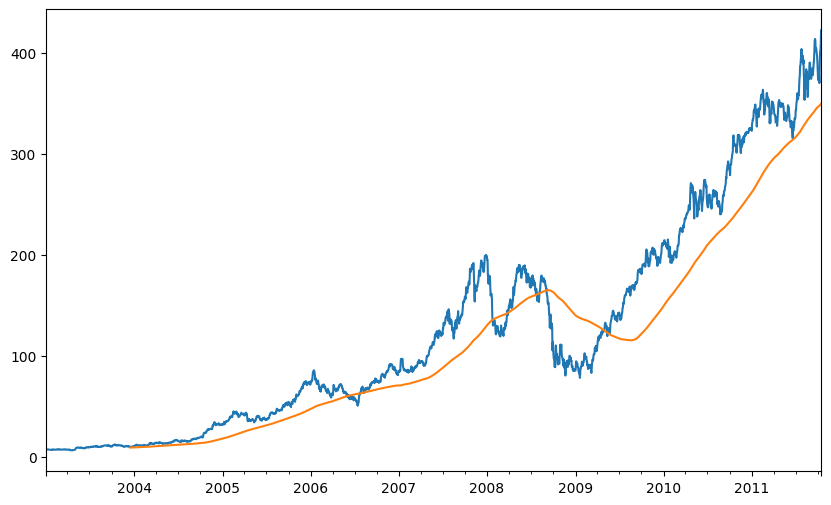

In [101]:
close_px["AAPL"].plot()
close_px["AAPL"].rolling(250).mean().plot()

<Axes: >

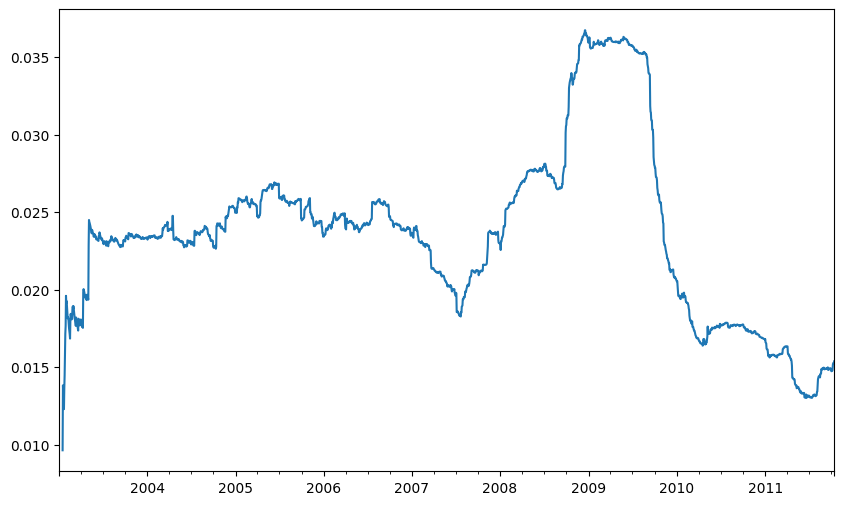

In [102]:
plt.figure()
std250 = close_px["AAPL"].pct_change().rolling(250, min_periods=10).std()
std250[5:12]
std250.plot()

In [105]:
expanding_mean = std250.expanding().mean()
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

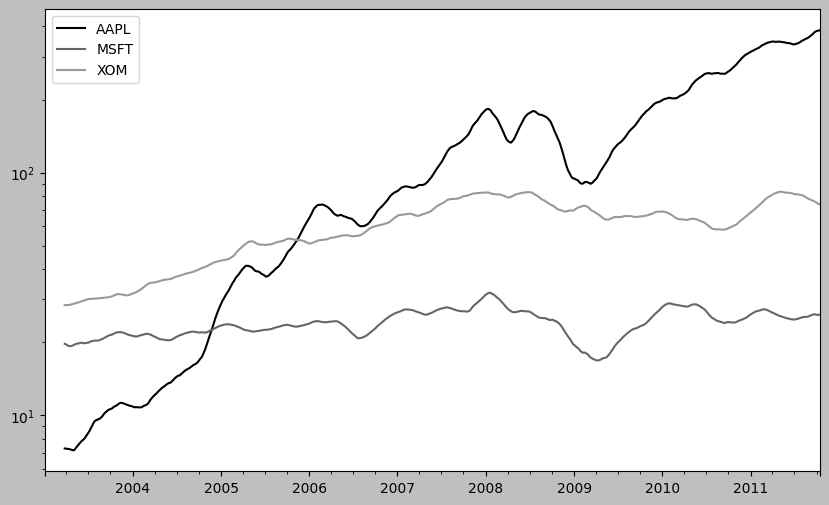

In [106]:
plt.style.use('grayscale')
close_px.rolling(60).mean().plot(logy=True)

In [107]:
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


In [108]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

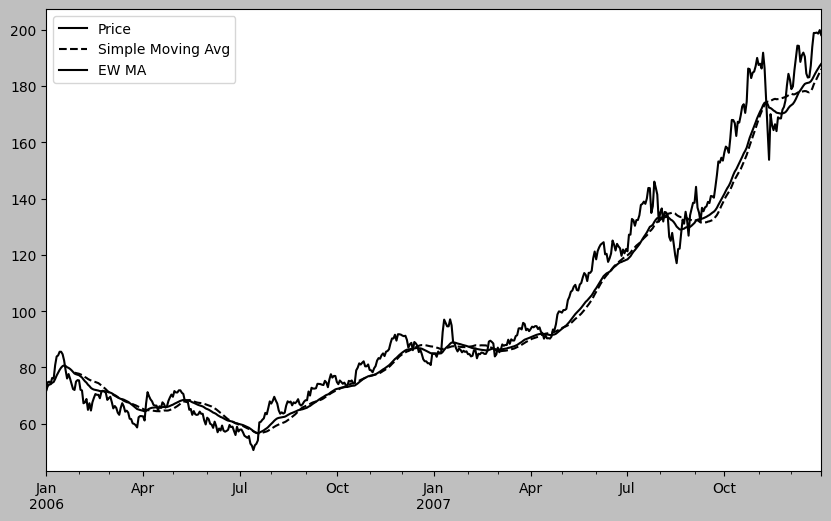

In [109]:
aapl_px = close_px["AAPL"]["2006":"2007"]

ma30 = aapl_px.rolling(30, min_periods=20).mean()
ewma30 = aapl_px.ewm(span=30).mean()

aapl_px.plot(style="k-", label="Price")
ma30.plot(style="k--", label="Simple Moving Avg")
ewma30.plot(style="k-", label="EW MA")
plt.legend()

In [110]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [112]:
spx_px = close_px_all["SPX"]
spx_rets = spx_px.pct_change()
returns = close_px.pct_change()

<Axes: >

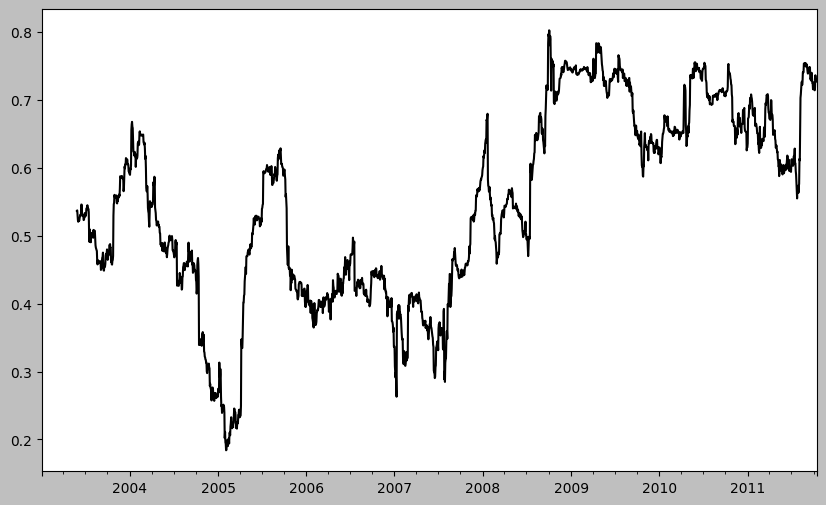

In [113]:
corr = returns["AAPL"].rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

In [114]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

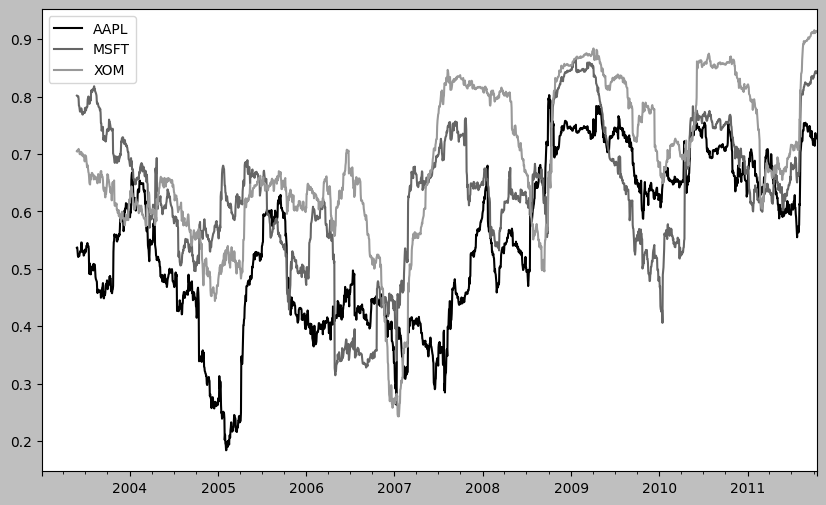

In [115]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

In [116]:
plt.figure()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

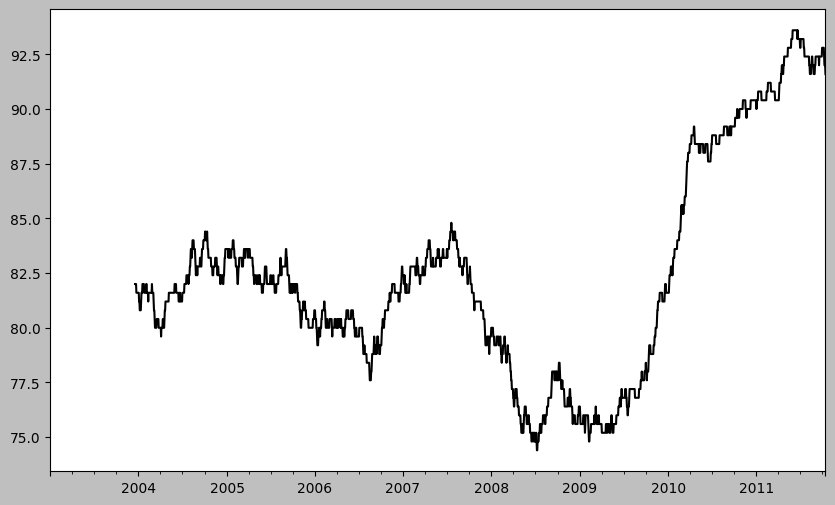

In [117]:
from scipy.stats import percentileofscore
def score_at_2percent(x):
    return percentileofscore(x, 0.02)

result = returns["AAPL"].rolling(250).apply(score_at_2percent)
result.plot()

In [118]:
pd.options.display.max_rows = PREVIOUS_MAX_ROWS